# Student Weak Subject Analysis

This notebook explores the student dataset using pandas and matplotlib.

This analysis focuses on grade-level differences in subject performance,
subject relationships, and the relationship between attendance and academic performance.

In [2]:
import pandas as pd

df = pd.read_csv("../data/student_data.csv")

df.head()

,student_id,grade,math,english,japanese,social,science,attendance
0,1,g1,33,69,78,18,20,74
1,2,g3,50,68,61,74,56,79
2,3,g2,58,43,46,41,66,75
3,4,g3,52,58,68,59,49,74
4,5,g2,57,65,69,97,53,76


In [3]:
df.shape

(300, 8)

In [4]:
df.describe()

,student_id,math,english,japanese,social,science,attendance
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,52.043333,58.213333,57.046667,57.470000,51.470000,76.200000
std,86.746758,17.513725,18.489475,20.615718,17.800523,19.890732,9.029124
min,1.000000,0.000000,11.000000,0.000000,0.000000,0.000000,53.000000
25%,75.750000,41.000000,45.000000,44.000000,47.000000,38.000000,70.000000
50%,150.500000,52.000000,60.000000,57.000000,58.000000,52.000000,76.000000
75%,225.250000,64.000000,72.000000,71.000000,68.000000,65.000000,82.000000
max,300.000000,99.000000,100.000000,100.000000,97.000000,100.000000,100.000000


## 1. Number of Students by Grade

In [5]:
df["grade"].value_counts().sort_index()

grade
g1     96
g2    104
g3    100
Name: count, dtype: int64

## 2. Average Score by Grade

In [6]:
df.groupby("grade")[
    ["math", "english", "japanese", "science", "social"]
].mean().round(2)

,math,english,japanese,science,social
grade,,,,,
g1,52.1,49.74,48.14,49.86,54.26
g2,50.2,58.12,57.59,51.00,55.45
g3,53.9,66.44,65.04,53.50,62.65


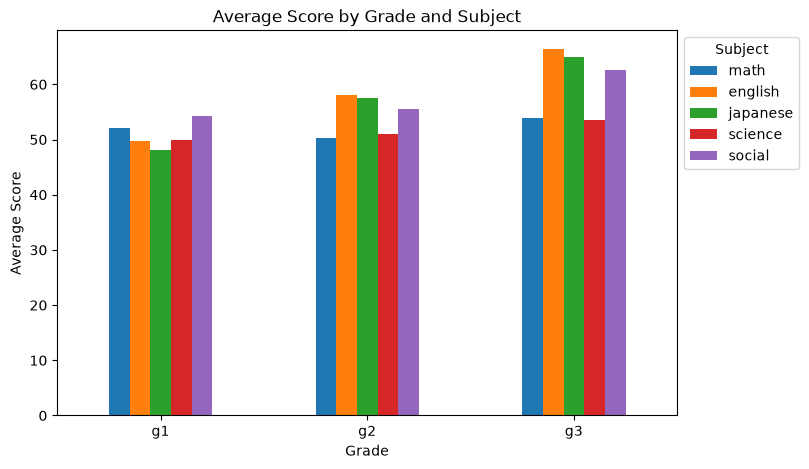

In [16]:
import matplotlib.pyplot as plt

grade_subject_avg = (
    df.groupby("grade")[
        ["math", "english", "japanese", "science", "social"]
    ]
    .mean()
    .round(2)
)

grade_subject_avg.plot(kind="bar", figsize=(8, 5))

plt.title("Average Score by Grade and Subject")
plt.xlabel("Grade")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject", loc="upper left", bbox_to_anchor=(1, 1))

plt.savefig("../images/average_score_by_grade.png",
            bbox_inches="tight")

plt.show()

## 3. Subject Relationships

Examine the relationships between related subjects.

In [7]:
df[["math", "science", "english", "japanese"]].corr().round(2)

,math,science,english,japanese
math,1.00,0.89,0.06,0.08
science,0.89,1.00,0.06,0.06
english,0.06,0.06,1.00,0.91
japanese,0.08,0.06,0.91,1.00


## 4. Weak Subject Analysis

Compare the overall average score for each subject to identify weaker subjects.

In [8]:
subject_avg = (
    df[["math", "english", "japanese", "science", "social"]]
    .mean()
    .round(2)
)

subject_avg.sort_values()

science     51.47
math        52.04
japanese    57.05
social      57.47
english     58.21
dtype: float64

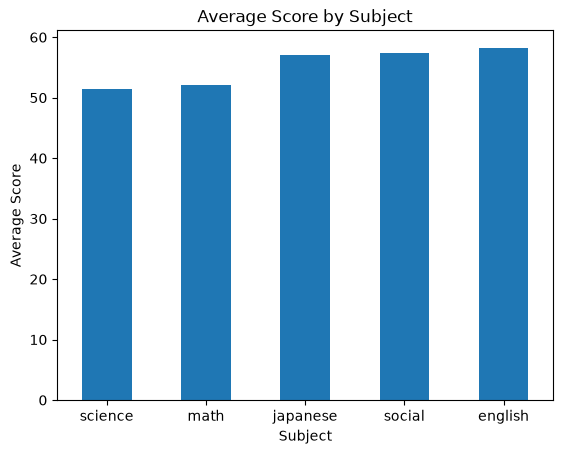

In [9]:
subject_avg.sort_values().plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.savefig("../images/average_score_by_subject.png",
            bbox_inches="tight")

plt.show()

## 5. Attendance and Academic Performance

Investigate the relationship between attendance and average score.

In [10]:
df["average_score"] = (
    df[["math", "english", "japanese", "science", "social"]]
    .mean(axis=1)
    .round(2)
)

In [11]:
df["attendance"].corr(df["average_score"]).round(2)

np.float64(0.39)

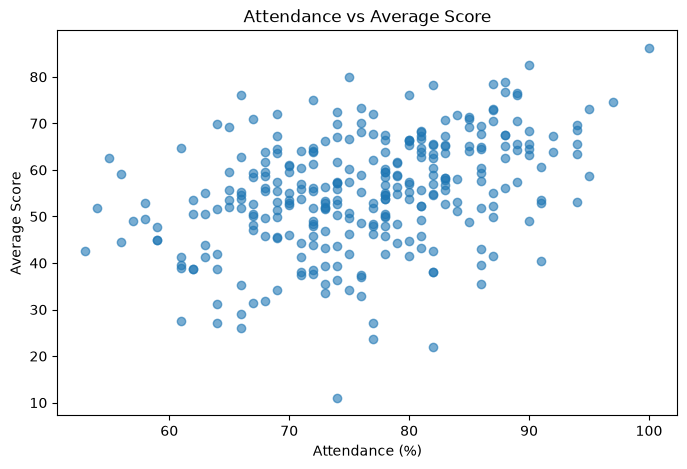

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(df["attendance"], df["average_score"], alpha=0.6)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")

plt.savefig("../images/attendance_vs_average.png",
            bbox_inches="tight")

plt.show()

## 6. Attendance and Academic Performance by Grade

Investigate whether the relationship between attendance and average score differs by grade.

In [13]:
grade_corr = (
    df.groupby("grade")
    .apply(lambda x: x["attendance"].corr(x["average_score"]))
    .round(2)
)

grade_corr

grade
g1    0.24
g2    0.43
g3    0.57
dtype: float64